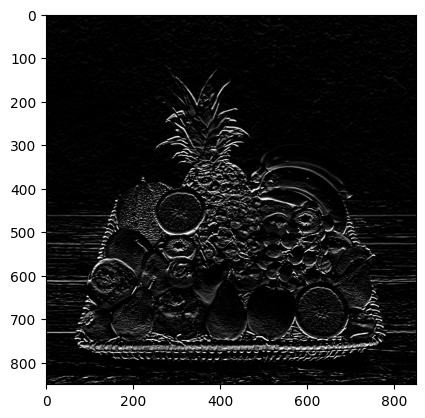

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Sample code for applying a convolution kernel
image = cv2.imread('/content/drive/MyDrive/main.jpg', cv2.IMREAD_GRAYSCALE)
kernel = np.array([[1, 2, 1], [0, 0, 0], [-1,-2,-1]]) # Example kernel (Sobel edge detection)
convolved_image = cv2.filter2D(image, -1, kernel)
plt.imshow(convolved_image, cmap='gray')
plt.show()

In [7]:
def box_filt(n):
    """
    Creates a box filter kernel of size n x n.
    """
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    # Create a kernel with all elements equal to
    # 1/(n*n)
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel

In [8]:
import copy
import numpy as np

def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size,pad_size),(pad_size,
                                                           pad_size)), mode='symmetric')
    image_box = copy.deepcopy(image_input)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            # image_input[i,j] = 0
            patch_curr = image_padded[i:i + filt_size,
                                      j:j + filt_size]
            results_box = box * patch_curr
            image_box[i,j] = np.sum(results_box)
    return image_box

1. Apply histogram equalization to an image and observe the effect on contrast.

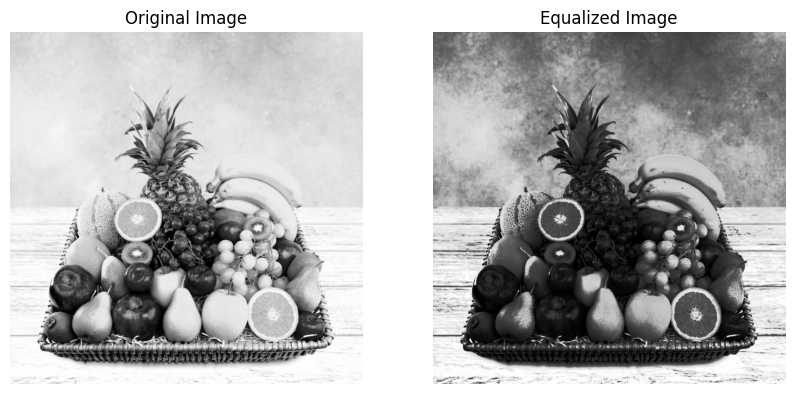

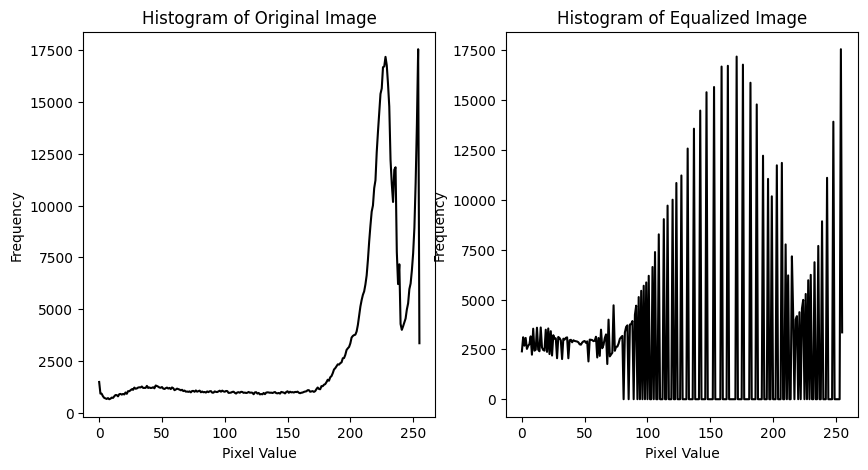

In [11]:
import cv2
import matplotlib.pyplot as plt

equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.show()

hist_original = cv2.calcHist([image], [0], None, [256], [0, 256])
hist_equalized = cv2.calcHist([equalized_image], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_original, color='black')
plt.title('Histogram of Original Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.plot(hist_equalized, color='black')
plt.title('Histogram of Equalized Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.show()

# Part 2

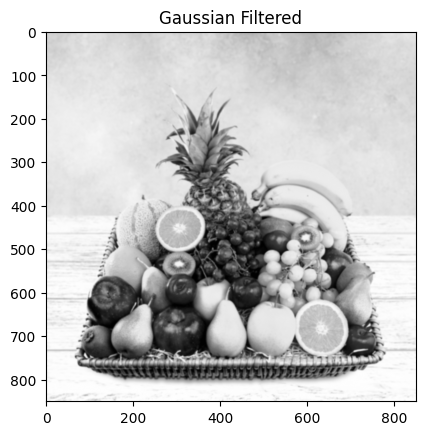

In [13]:
# Applying a Gaussian filter
gaussian_filtered_image = cv2.GaussianBlur(image,(5, 5), 0)
plt.imshow(gaussian_filtered_image, cmap='gray')
plt.title('Gaussian Filtered')
plt.show()

In [14]:
def gauss_filt(n, sigma=1.0):
    """
    Creates a Gaussian filter kernel of size n x n
    with standard deviation sigma.
    """
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    # Create a Gaussian kernel
    ax = np.linspace(-(n - 1) / 2., (n - 1) / 2., n)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

In [17]:
import numpy as np

n = 5  # Example window size, must be a positive odd integer
sigma = 1.0 # Example standard deviation

ax = np.linspace(-(n - 1) / 2., (n - 1) / 2., n)
xx, yy = np.meshgrid(ax, ax)

kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
kernel = kernel / np.sum(kernel) # Corrected typo and added normalization

# Part 3: Unsharp Masking

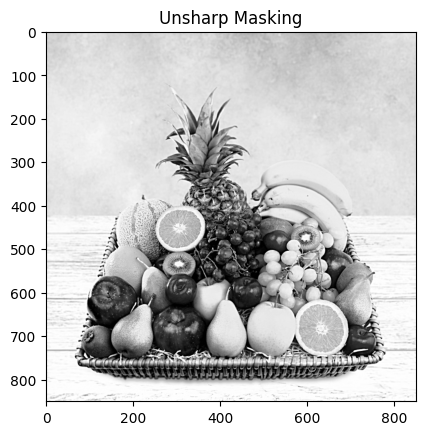

In [18]:
blurred = cv2.GaussianBlur(image, (9, 9), 10)
unsharp_image = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)
plt.imshow(unsharp_image, cmap='gray')
plt.title('Unsharp Masking')
plt.show()

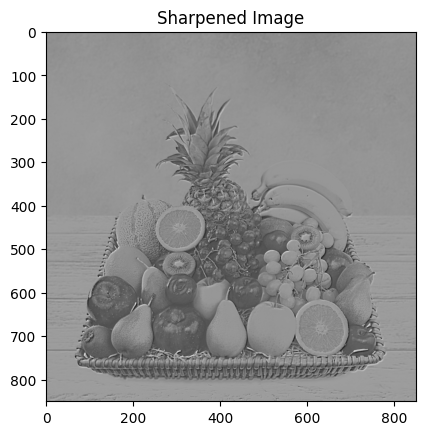

In [22]:
import copy
import cv2
import numpy as np
from matplotlib import pyplot as plt

def box_filt(n):
    """
    Creates a box filter kernel of size n x n.
    """
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    # Create a kernel with all elements equal to
    # 1/(n*n)
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel

def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))
    # pad_size = pad_size.astype('uint8')
    # print(pad_size.dtype)
    image_padded = np.pad(image_input,
                          pad_width=((pad_size,pad_size),(pad_size,
                                                           pad_size)), mode='symmetric')
    image_box = copy.deepcopy(image_input)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            # image_input[i,j] = 0
            patch_curr = image_padded[i:i + filt_size,
                                      j:j + filt_size]
            results_box = box * patch_curr
            image_box[i,j] = np.sum(results_box)
    return image_box

filt_size = 5
k = 2

image_input = cv2.imread('/content/drive/MyDrive/main.jpg',
0).astype('float32')/255
box = box_filt(filt_size)
image_blur = apply_filters(image_input, box,
filt_size)
image_diff = image_input - image_blur
image_sharp = image_input+k*image_diff
plt.imshow(image_sharp, cmap='gray') # Changed cv2.imshow to plt.imshow for Colab compatibility
plt.title('Sharpened Image')
plt.show() # Added plt.show() for display
# cv2.waitKey(-1) # Removed as it's not suitable for Colab

# Task 4

In [ ]:
"""Using the source code provided above, use various combinations of parameters filt_size
and k and write down the impact of their variations. Use various filt_size such as 3, 5, 7,
9, 11, 15 as well as various values of k such as -2, -1, -0.5, 0, 0.5, 1, 2, 3, 5, 9"""


# Task
Iterate through various combinations of `filt_size` (3, 5, 7, 9, 11, 15) and `k` (-2, -1, -0.5, 0, 0.5, 1, 2, 3, 5, 9), apply unsharp masking to `main.jpg` for each combination, display the resulting images, and analyze the visual impact of these parameter variations.

## Iterate and Apply Unsharp Masking

### Subtask:
Modify the selected cell to implement loops for `filt_size` and `k` to apply unsharp masking with various combinations of parameters and display the resulting images.


**Reasoning**:
The subtask requires modifying the existing code to iterate through various `filt_size` and `k` values for unsharp masking. I will add lists for these parameters and implement nested loops to apply the unsharp masking process for each combination, displaying the results with descriptive titles.



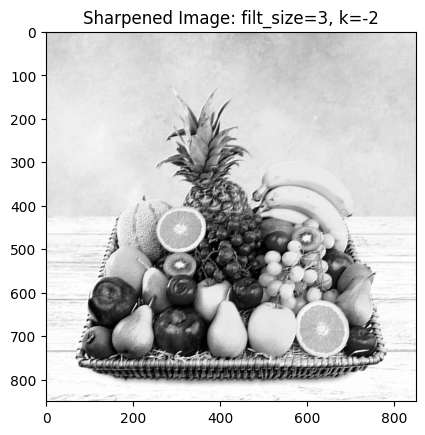

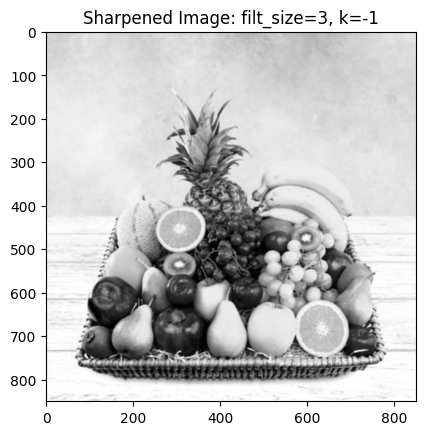

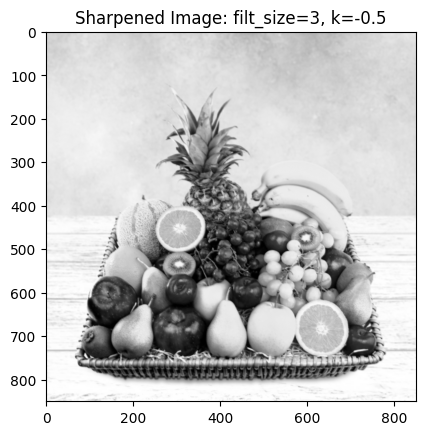

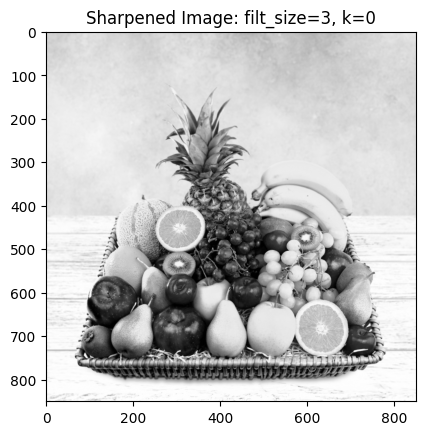

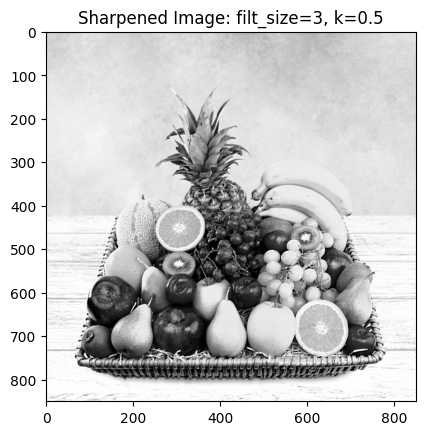

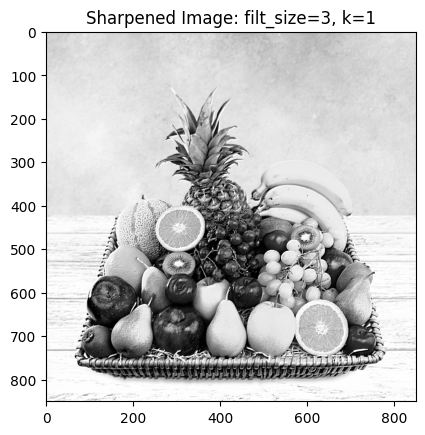

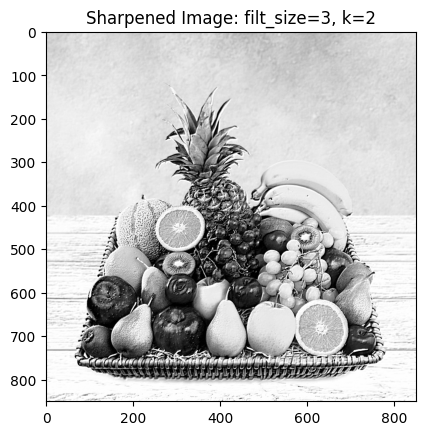

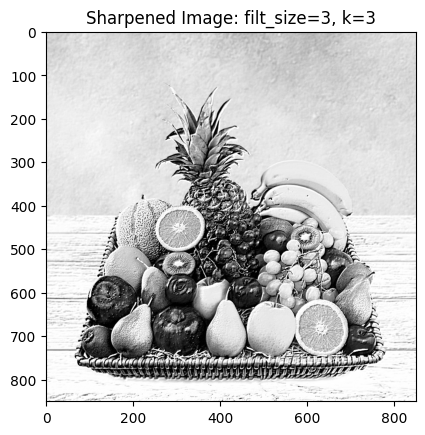

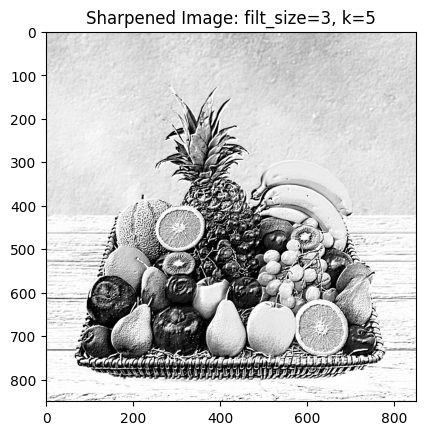

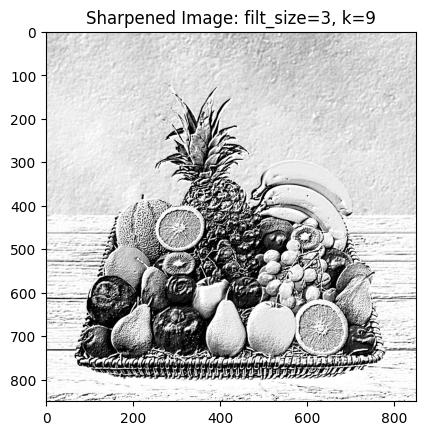

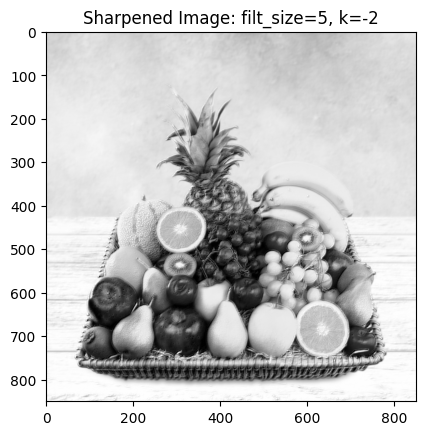

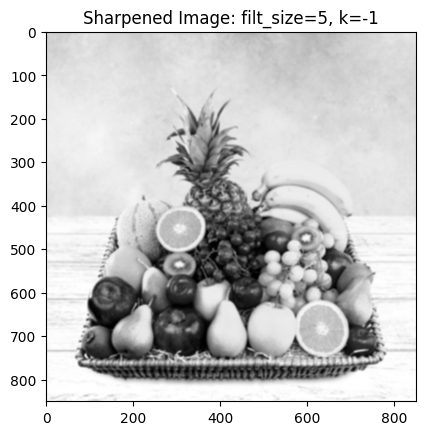

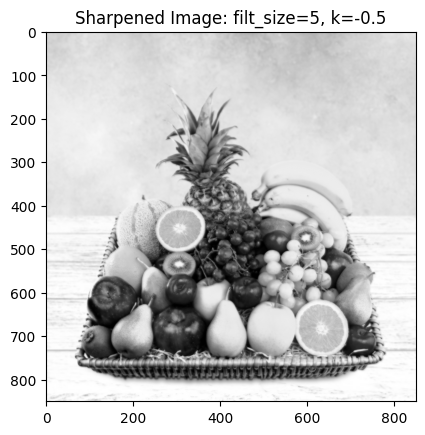

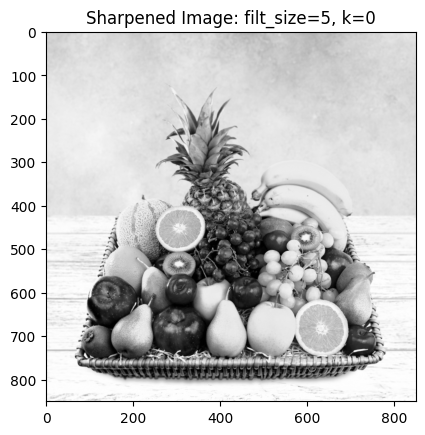

KeyboardInterrupt: 

In [23]:
import copy
import cv2
import numpy as np
from matplotlib import pyplot as plt

def box_filt(n):
    """
    Creates a box filter kernel of size n x n.
    """
    if n <= 0 or n % 2 == 0:
        raise ValueError("Window size must be a positive odd integer.")
    # Create a kernel with all elements equal to
    # 1/(n*n)
    kernel = np.ones((n, n), np.float32) / (n * n)
    return kernel

def apply_filters(image_input, box, filt_size):
    pad_size = int(np.ceil(filt_size/2))
    image_padded = np.pad(image_input,
                          pad_width=((pad_size,pad_size),(pad_size,
                                                           pad_size)), mode='symmetric')
    image_box = copy.deepcopy(image_input)
    row, column = image_input.shape
    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i + filt_size,
                                      j:j + filt_size]
            results_box = box * patch_curr
            image_box[i,j] = np.sum(results_box)
    return image_box

image_input = cv2.imread('/content/drive/MyDrive/main.jpg', 0).astype('float32')/255

# Define lists for filt_size and k values
filt_sizes = [3, 5, 7, 9, 11, 15]
k_values = [-2, -1, -0.5, 0, 0.5, 1, 2, 3, 5, 9]

for filt_size in filt_sizes:
    for k in k_values:
        # a. Create a box filter kernel
        box = box_filt(filt_size)

        # b. Apply the box filter to get image_blur
        image_blur = apply_filters(image_input, box, filt_size)

        # c. Calculate the difference image
        image_diff = image_input - image_blur

        # d. Calculate the sharpened image
        image_sharp = image_input + k * image_diff

        # Ensure image values are within [0, 1] range for proper display
        image_sharp = np.clip(image_sharp, 0, 1)

        # e. Display the image_sharp
        plt.imshow(image_sharp, cmap='gray')

        # f. Set the title of the plot
        plt.title(f'Sharpened Image: filt_size={filt_size}, k={k}')

        # g. Use plt.show() to display each image
        plt.show()
